In [3]:
import os, glob, random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB4

# ================= PATHS (Fixed for Windows) =================
CT_ROOT = r"C:\Users\shrey\OneDrive\Desktop\mini project\Topics\Brain tumor multimodal image (CT & MRI)\Dataset\Brain Tumor CT scan Images"
MRI_ROOT = r"C:\Users\shrey\OneDrive\Desktop\mini project\Topics\Brain tumor multimodal image (CT & MRI)\Dataset\Brain Tumor MRI images"

# ================= LOAD DATA =================
def load_images(root):
    healthy = glob.glob(os.path.join(root,"Healthy","*"))
    tumor   = glob.glob(os.path.join(root,"Tumor","*"))

    healthy = [p for p in healthy if p.lower().endswith((".png",".jpg",".jpeg"))]
    tumor   = [p for p in tumor   if p.lower().endswith((".png",".jpg",".jpeg"))]

    print(f"\n{os.path.basename(root)}")
    print("Healthy:", len(healthy))
    print("Tumor :", len(tumor))

    paths  = healthy + tumor
    labels = [0]*len(healthy) + [1]*len(tumor)

    data=list(zip(paths,labels))
    random.shuffle(data)
    paths,labels=zip(*data)

    return list(paths),list(labels)

ct_paths, ct_labels = load_images(CT_ROOT)
mri_paths, mri_labels = load_images(MRI_ROOT)


Brain Tumor CT scan Images
Healthy: 2300
Tumor : 2318

Brain Tumor MRI images
Healthy: 2000
Tumor : 3000


In [4]:
# ===== Split =====
def split(paths, labels):
    s1=int(0.7*len(paths))
    s2=int(0.85*len(paths))
    return paths[:s1],paths[s1:s2],paths[s2:],labels[:s1],labels[s1:s2],labels[s2:]

ct_train_p, ct_val_p, ct_test_p, ct_train_l, ct_val_l, ct_test_l = split(ct_paths, ct_labels)
mri_train_p, mri_val_p, mri_test_p, mri_train_l, mri_val_l, mri_test_l = split(mri_paths, mri_labels)

IMG_SIZE=(300,300)

def load_ct(path,label):
    img=tf.io.read_file(path)
    img=tf.image.decode_image(img,channels=3,expand_animations=False)
    img=tf.image.resize(img,IMG_SIZE)
    img=tf.cast(img,tf.float32)/255.0
    img=(img-0.5)/0.5
    return img,tf.cast(label,tf.float32)

def load_mri(path,label):
    img=tf.io.read_file(path)
    img=tf.image.decode_image(img,channels=3,expand_animations=False)
    img=tf.image.resize(img,IMG_SIZE)
    img=tf.cast(img,tf.float32)/255.0
    img=(img-tf.reduce_mean(img))/(tf.math.reduce_std(img)+1e-6)
    return img,tf.cast(label,tf.float32)

def make_ds(paths,labels,loader,shuffle=False):
    ds=tf.data.Dataset.from_tensor_slices((paths,labels))
    ds=ds.map(loader,num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle: ds=ds.shuffle(2000)
    return ds.batch(8).prefetch(tf.data.AUTOTUNE)

ct_train=make_ds(ct_train_p,ct_train_l,load_ct,True)
ct_val=make_ds(ct_val_p,ct_val_l,load_ct)
ct_test=make_ds(ct_test_p,ct_test_l,load_ct)

mri_train=make_ds(mri_train_p,mri_train_l,load_mri,True)
mri_val=make_ds(mri_val_p,mri_val_l,load_mri)
mri_test=make_ds(mri_test_p,mri_test_l,load_mri)

print("Datasets ready ✅")

Datasets ready ✅


In [5]:
def build_classifier():
    base=EfficientNetB4(include_top=False,weights="imagenet",
                        input_shape=(300,300,3))
    base.trainable=False

    x=layers.GlobalAveragePooling2D()(base.output)
    x=layers.BatchNormalization()(x)
    x=layers.Dense(512,activation="relu")(x)
    x=layers.Dropout(0.4)(x)
    out=layers.Dense(1,activation="sigmoid")(x)

    model=models.Model(base.input,out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

# ---------- CT ----------
print("Training CT model... (This will take time)")
ct_model=build_classifier()
ct_model.fit(ct_train,validation_data=ct_val,epochs=4)

for l in ct_model.layers[-40:]:
    l.trainable=True

ct_model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                 loss="binary_crossentropy",
                 metrics=["accuracy"])

ct_model.fit(ct_train,validation_data=ct_val,epochs=6)

# ---------- MRI ----------
print("Training MRI model... (This will take time)")
mri_model=build_classifier()
mri_model.fit(mri_train,validation_data=mri_val,epochs=4)

for l in mri_model.layers[-40:]:
    l.trainable=True

mri_model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])

mri_model.fit(mri_train,validation_data=mri_val,epochs=6)

Training CT model... (This will take time)
71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/4
404/404 ━━━━━━━━━━━━━━━━━━━━ 665s 2s/step - accuracy: 0.7287 - loss: 0.9142 - val_accuracy: 0.8355 - val_loss: 0.3672
Epoch 2/4
404/404 ━━━━━━━━━━━━━━━━━━━━ 595s 1s/step - accuracy: 0.7692 - loss: 0.6008 - val_accuracy: 0.8658 - val_loss: 0.3048
Epoch 3/4
404/404 ━━━━━━━━━━━━━━━━━━━━ 578s 1s/step - accuracy: 0.7850 - loss: 0.4665 - val_accuracy: 0.8730 - val_loss: 0.3372
Epoch 4/4
404/404 ━━━━━━━━━━━━━━━━━━━━ 569s 1s/step - accuracy: 0.8140 - loss: 0.4157 - val_accuracy: 0.8773 - val_loss: 0.2951
Epoch 1/6
404/404 ━━━━━━━━━━━━━━━━━━━━ 712s 2s/step - accuracy: 0.7710 - loss: 0.4745 - val_accuracy: 0.8499 - val_loss: 0.3450
Epoch 2/6
404/404 ━━━━━━━━━━━━━━━━━━━━ 703s 2s/step - accuracy: 0.8202 - loss: 0.3893 - val_accuracy: 0.8701 - val_loss: 0.3179
Epoch 3/6
404/404 ━━━━━━━━━━━━━━━━━━━━ 708s 2s/step - accuracy: 0.8292 - loss: 0.3581 - val_accuracy: 0.8759 - val_loss: 0.2983
Epoch 4/6


In [6]:
# feature extractors (remove final sigmoid layer)
ct_extractor=models.Model(ct_model.input, ct_model.layers[-2].output)
mri_extractor=models.Model(mri_model.input, mri_model.layers[-2].output)

def extract(model,ds):
    f,l=[],[]
    for x,y in ds:
        f.append(model(x,training=False).numpy())
        l.append(y.numpy())
    return np.concatenate(f),np.concatenate(l)

print("Extracting features...")
ct_train_feat, ct_train_lab = extract(ct_extractor, ct_train)
ct_val_feat, ct_val_lab     = extract(ct_extractor, ct_val)
ct_test_feat, ct_test_lab   = extract(ct_extractor, ct_test)

mri_train_feat, mri_train_lab = extract(mri_extractor, mri_train)
mri_val_feat, mri_val_lab     = extract(mri_extractor, mri_val)
mri_test_feat, mri_test_lab   = extract(mri_extractor, mri_test)
print("Features extracted! ✅")

Extracting features...
Features extracted! ✅


In [7]:
from sklearn.metrics import classification_report, confusion_matrix

def fuse_by_class(ct_feat, ct_lab, mri_feat, mri_lab):
    ct_h = ct_feat[ct_lab == 0]
    ct_t = ct_feat[ct_lab == 1]

    mri_h = mri_feat[mri_lab == 0]
    mri_t = mri_feat[mri_lab == 1]

    n_h = min(len(ct_h), len(mri_h))
    n_t = min(len(ct_t), len(mri_t))

    idx_ct_h  = np.random.choice(len(ct_h), n_h, replace=False)
    idx_mri_h = np.random.choice(len(mri_h), n_h, replace=False)

    idx_ct_t  = np.random.choice(len(ct_t), n_t, replace=False)
    idx_mri_t = np.random.choice(len(mri_t), n_t, replace=False)

    healthy = np.concatenate([ct_h[idx_ct_h], mri_h[idx_mri_h]], axis=1)
    tumor   = np.concatenate([ct_t[idx_ct_t], mri_t[idx_mri_t]], axis=1)

    X = np.vstack([healthy, tumor])
    y = np.array([0]*n_h + [1]*n_t)

    return X, y

X_train, y_train = fuse_by_class(ct_train_feat, ct_train_lab, mri_train_feat, mri_train_lab)
X_val, y_val = fuse_by_class(ct_val_feat, ct_val_lab, mri_val_feat, mri_val_lab)
X_test, y_test = fuse_by_class(ct_test_feat, ct_test_lab, mri_test_feat, mri_test_lab)

def fusion_model(input_dim):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(512, activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu")(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    return models.Model(inp, out)

model = fusion_model(X_train.shape[1])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss="binary_crossentropy", metrics=["accuracy"])

print("Training Fusion model...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print("\n✅ Fusion Test Accuracy:", acc)

Training Fusion model...
Epoch 1/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9218 - loss: 0.1943 - val_accuracy: 0.9843 - val_loss: 0.0465
Epoch 2/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9862 - loss: 0.0480 - val_accuracy: 0.9859 - val_loss: 0.0400
Epoch 3/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9901 - loss: 0.0318 - val_accuracy: 0.9859 - val_loss: 0.0358
Epoch 4/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9938 - loss: 0.0225 - val_accuracy: 0.9875 - val_loss: 0.0342
Epoch 5/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9918 - loss: 0.0210 - val_accuracy: 0.9875 - val_loss: 0.0329
Epoch 6/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9957 - loss: 0.0138 - val_accuracy: 0.9906 - val_loss: 0.0332
Epoch 7/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9947 - loss: 0.0149 - val_accuracy: 0.9906 - val_loss: 0.0319
Epoch 8/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9967 - loss: 0.0106 - 

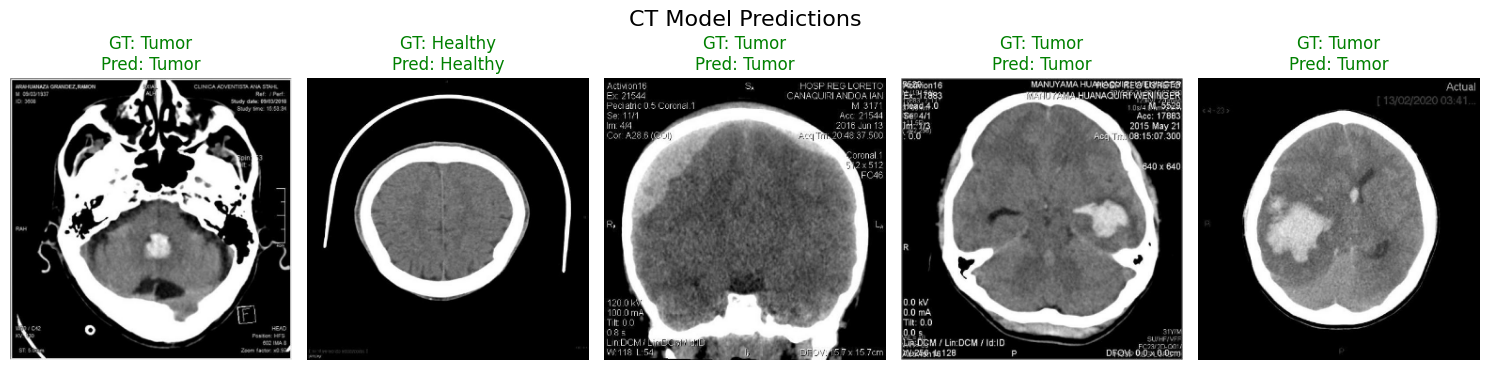

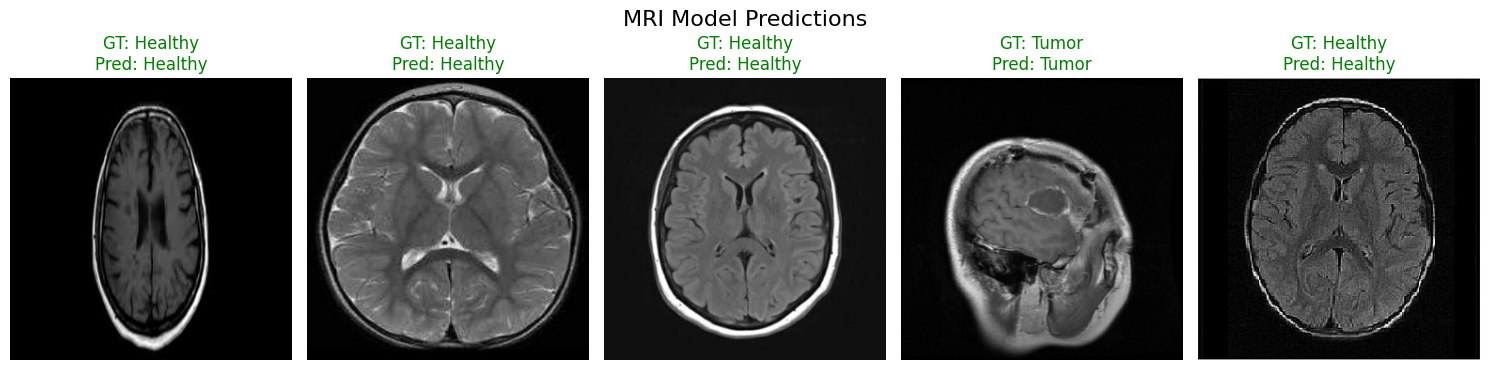

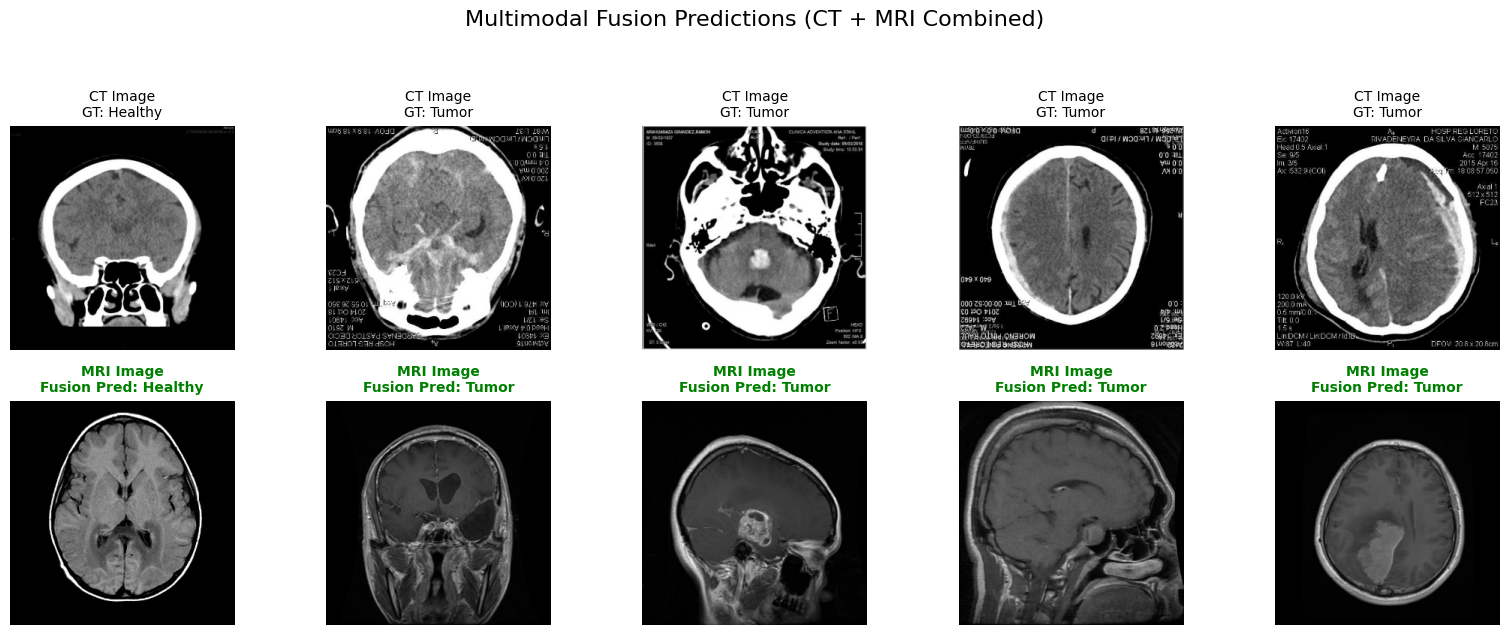

In [8]:
import matplotlib.pyplot as plt

def plot_single_modality(mod_model, dataset, title, num_images=5):
    plt.figure(figsize=(15, 4))
    for images, labels in dataset.take(1):
        preds = mod_model.predict(images, verbose=0)
        for i in range(min(num_images, len(images))):
            ax = plt.subplot(1, num_images, i + 1)
            img = images[i].numpy()
            
            # Reverse normalizations so images look normal
            if title == "CT":
                img = img * 0.5 + 0.5
            else:
                img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-6)
                
            plt.imshow(np.clip(img, 0, 1))
            gt_class = "Tumor" if int(labels[i].numpy()) == 1 else "Healthy"
            pred_class = "Tumor" if preds[i][0] > 0.5 else "Healthy"
            plt.title(f"GT: {gt_class}\nPred: {pred_class}", color="green" if gt_class == pred_class else "red")
            plt.axis("off")
            
    plt.suptitle(f"{title} Model Predictions", fontsize=16)
    plt.tight_layout()
    plt.show()

# Print CT and MRI standalone predictions
plot_single_modality(ct_model, ct_test, "CT")
plot_single_modality(mri_model, mri_test, "MRI")

# --- Multimodal Fusion Visualizer ---
def plot_fusion_predictions(fusion_model, ct_p_list, ct_l_list, mri_p_list, mri_l_list, num_pairs=5):
    plt.figure(figsize=(16, 6))
    
    ct_h = [p for p, l in zip(ct_p_list, ct_l_list) if l == 0]
    ct_t = [p for p, l in zip(ct_p_list, ct_l_list) if l == 1]
    mri_h = [p for p, l in zip(mri_p_list, mri_l_list) if l == 0]
    mri_t = [p for p, l in zip(mri_p_list, mri_l_list) if l == 1]
    
    for i in range(num_pairs):
        gt_label = random.choice([0, 1])
        
        if gt_label == 0:
            ct_p, mri_p = random.choice(ct_h), random.choice(mri_h)
        else:
            ct_p, mri_p = random.choice(ct_t), random.choice(mri_t)
            
        ct_img, _ = load_ct(ct_p, gt_label)
        mri_img, _ = load_mri(mri_p, gt_label)
        
        ct_batch = tf.expand_dims(ct_img, 0)
        mri_batch = tf.expand_dims(mri_img, 0)
        
        ct_feat = ct_extractor.predict(ct_batch, verbose=0)
        mri_feat = mri_extractor.predict(mri_batch, verbose=0)
        
        fused_feat = np.concatenate([ct_feat, mri_feat], axis=1)
        pred_prob = fusion_model.predict(fused_feat, verbose=0)[0][0]
        pred_label = 1 if pred_prob > 0.5 else 0
        
        gt_str = "Tumor" if gt_label == 1 else "Healthy"
        pred_str = "Tumor" if pred_label == 1 else "Healthy"
        color = "green" if gt_label == pred_label else "red"
        
        ax_ct = plt.subplot(2, num_pairs, i + 1)
        disp_ct = ct_img.numpy() * 0.5 + 0.5
        plt.imshow(np.clip(disp_ct, 0, 1))
        plt.title(f"CT Image\nGT: {gt_str}", fontsize=10)
        plt.axis("off")
        
        ax_mri = plt.subplot(2, num_pairs, i + num_pairs + 1)
        disp_mri = mri_img.numpy()
        disp_mri = (disp_mri - np.min(disp_mri)) / (np.max(disp_mri) - np.min(disp_mri) + 1e-6)
        plt.imshow(np.clip(disp_mri, 0, 1))
        plt.title(f"MRI Image\nFusion Pred: {pred_str}", color=color, fontsize=10, fontweight='bold')
        plt.axis("off")

    plt.suptitle("Multimodal Fusion Predictions (CT + MRI Combined)", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

# Print Multimodal paired predictions
plot_fusion_predictions(model, ct_test_p, ct_test_l, mri_test_p, mri_test_l, num_pairs=5)

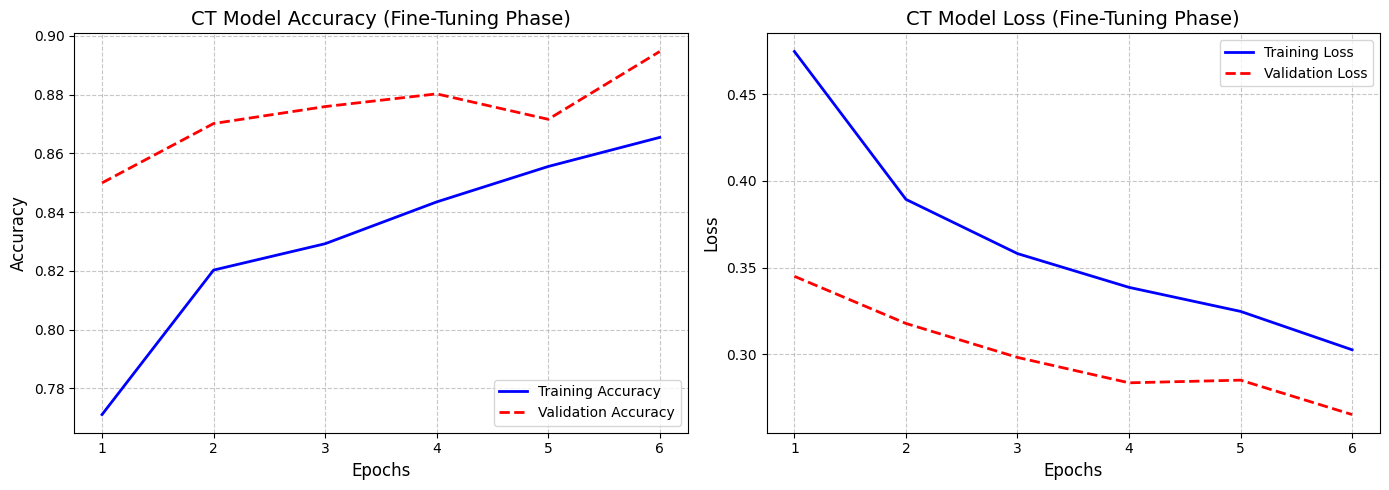

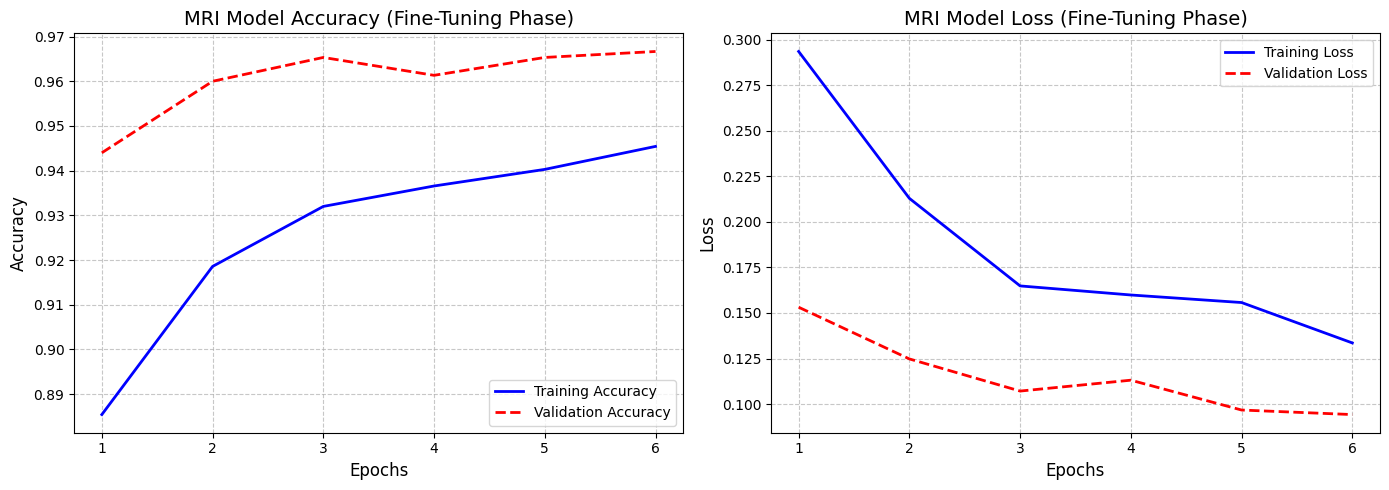

In [10]:
def plot_single_history(model, title):
    # Keras automatically saves the history of the last .fit() call in model.history
    if model.history is None:
        print(f"No history found for {title}. You might need to train it first.")
        return
        
    history_dict = model.history.history
    
    acc = history_dict['accuracy']
    val_acc = history_dict['val_accuracy']
    loss = history_dict['loss']
    val_loss = history_dict['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # 1. Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy', linewidth=2)
    plt.plot(epochs, val_acc, 'r--', label='Validation Accuracy', linewidth=2)
    plt.title(f'{title} Model Accuracy (Fine-Tuning Phase)', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)

    # 2. Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss', linewidth=2)
    plt.plot(epochs, val_loss, 'r--', label='Validation Loss', linewidth=2)
    plt.title(f'{title} Model Loss (Fine-Tuning Phase)', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Plot the CT Model Graphs
plot_single_history(ct_model, "CT")

# Plot the MRI Model Graphs
plot_single_history(mri_model, "MRI")

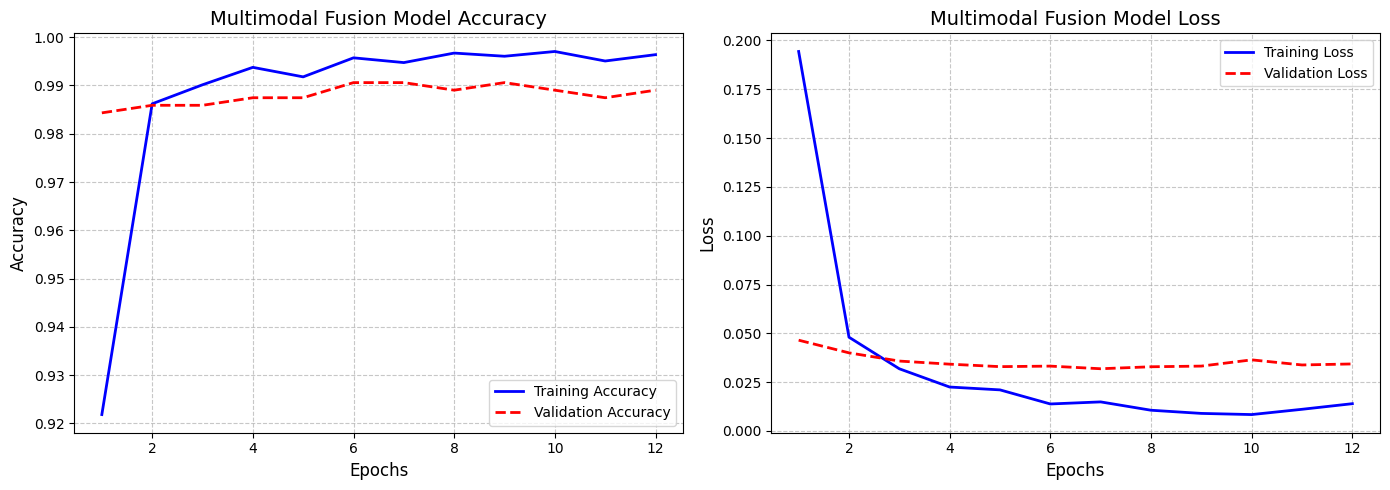

In [9]:
import matplotlib.pyplot as plt

def plot_training_history(history_obj):
    # Extract data from the history object
    acc = history_obj.history['accuracy']
    val_acc = history_obj.history['val_accuracy']
    loss = history_obj.history['loss']
    val_loss = history_obj.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # 1. Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy', linewidth=2)
    plt.plot(epochs, val_acc, 'r--', label='Validation Accuracy', linewidth=2)
    plt.title('Multimodal Fusion Model Accuracy', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)

    # 2. Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss', linewidth=2)
    plt.plot(epochs, val_loss, 'r--', label='Validation Loss', linewidth=2)
    plt.title('Multimodal Fusion Model Loss', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Plot the graphs using the saved 'history' variable from Cell 5
plot_training_history(history)